# Evaluación Parcial 2 – MLY0100: Machine Learning

Desarrollo de un modelo de Machine Learning supervisado (Regresión y Clasificación) en Jupyter Notebook.

Este notebook corresponde al instrumento de evaluación. Lea cuidadosamente las instrucciones en cada sección y complete las celdas de código y de texto indicadas.


## 0.1 Resultados de aprendizaje evaluados (resumen)

Este instrumento evalúa, entre otros, los siguientes aspectos del curso:

- Aplicación de algoritmos de **regresión** y **clasificación** en problemas reales.
- Uso de métricas de evaluación para modelos de regresión y clasificación.
- Diferenciación entre tareas de regresión (target continuo) y clasificación (target discreto).
- Análisis de correlación entre *features* y selección/transformación de atributos (ingeniería de características).
- Identificación de **overfitting** y **underfitting**.
- Uso de técnicas de **balanceo de clases** para mejorar la generalización.
- Selección y justificación del modelo más adecuado según métricas y contexto del caso.


In [ ]:
# =====================================================
# 0. Preparación del entorno y librerías
# =====================================================

# En Google Colab, la mayoría de estas librerías ya viene instalada.
# Si necesita instalar alguna adicional (por ejemplo, imbalanced-learn),
# puede descomentar la siguiente línea.

# !pip install -q imbalanced-learn

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Si decide usar técnicas de balanceo de clases basadas en imbalanced-learn,
# recuerde descomentar la instalación más arriba.
try:
    from imblearn.over_sampling import RandomOverSampler
except ImportError:
    RandomOverSampler = None
    print("Advertencia: imbalanced-learn no está instalado. "
          "Si necesita técnicas de balanceo como RandomOverSampler, "
          "instálelas en una celda aparte.")


# 1. Fase CRISP-DM: Comprensión del negocio

En esta sección debe describir el contexto del caso, el problema de negocio y los objetivos que se espera lograr mediante el uso de Machine Learning.
Use la información entregada en el enunciado del caso.


### 1.1 Contexto del caso y problema de negocio

Describa en máximo 4 líneas el contexto del caso (organización, proceso, tipo de datos) y el problema de negocio que se desea abordar.

**Respuesta (complete aquí): El caso analiza una dataset de vinos y sus propiedades. El problema de negocio es clasificar automaticamente cada vino en su cultivar correcto (clase 0,1 o 2) para asegurar el control de calidad. El objetivo es implementar cuatro modelos de clasificacion para predecir la columna target y dos modelos de regresion para predecir una columna continua (como alchol). Seleccionando el mejor modelo para cada tarea basandose en su metrica.


### 1.2 Objetivo de negocio y objetivo analítico

1. Formule el **objetivo de negocio** principal que se busca alcanzar con el modelo de Machine Learning.
2. Formule el **objetivo analítico** (en términos de predicción/estimación de variables mediante ML).

**Respuesta (complete aquí): El obetivo de neogico principal es automatizar y mejorar la precicion del control de calidad en la catalogacion de los vinos. Buscamos que la viña pueda usar el modelo machine learning para clasificar sus vinos de forma eficiente y consistente. Esto ayuda a evitar errores en la asignacion de precios o en la denominacion de origen, asegurando que un vino del cultivar 0, por ejemplo, sea siempre reconocido como tal.

Para lograr el objetivo de negocio necesitamos clasificacion que seria el objetivo analitico es estimar una variable numerica categorica (target). El modelo debe clasificar un vino nuevo usando como fetures sus propiedades quimicas. Por ultimo seria la regresion el objetivo analitico es estimar variable numerica continua. Para este caso, elegimos alcohol como el target de regresion. El objetivo es predecir (o estimar) el grado de alcoholico exacto.


### 1.3 Variables relevantes desde la perspectiva del negocio

Identifique las variables (columnas del dataset) que considera más relevantes desde el punto de vista del negocio y explique brevemente por qué.

**Respuesta (complete aquí): Primero que nada, la columna target es clave. Define la categoria del vino (0,1 o 2), que es basicamente el objetivo de negocio, o sea, saber que tipo de vino es, caracteristicas obvias(consumidor) diria que las variables que un cliente puede "ver o "sentir" facilmente como el alcohol y tambien color_intensity(aspecto visual). Luego tenemos a las caracteristicas quimicas (calidad)  que suenan a cosa que tienen que ver con la validad, el sabor o la textura.


# 2. Fase CRISP-DM: Comprensión de los datos

En esta sección debe cargar el dataset del caso, revisar su estructura y realizar un primer análisis exploratorio básico.


In [ ]:
# 2.1 Carga del dataset

from sklearn.datasets import load_breast_cancer, load_wine

# TODO: seleccione el dataset con el cual quiera trabajar
#opcion_dataset = "breast_cancer"
opcion_dataset = "wine"

if opcion_dataset == "breast_cancer":
    data = load_breast_cancer(as_frame=True)
    df = data.frame.copy()
    contexto = "Diagnóstico de cáncer de mama (0 = benigno, 1 = maligno)."

elif opcion_dataset == "wine":
    data = load_wine(as_frame=True)
    df = data.frame.copy()
    contexto = "Clasificación de vino según propiedades físico-químicas."

else:
    raise ValueError("Opción de dataset no válida. Use 'breast_cancer' o 'wine'.")

print("Dataset seleccionado:", opcion_dataset)
print("Contexto del caso:", contexto)
print("Dimensiones del dataset:", df.shape)

# Vista rápida de los primeros registros
df.head()


Dataset seleccionado: wine
Contexto del caso: Clasificación de vino según propiedades físico-químicas.
Dimensiones del dataset: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [ ]:
# 2.2 Exploración básica de la estructura de los datos

print("Dimensiones del dataset (filas, columnas):", df.shape)

print("\nTipos de datos por columna:")
print(df.dtypes)

print("\nCantidad de valores faltantes por columna:")
print(df.isna().sum())


Dimensiones del dataset (filas, columnas): (178, 14)

Tipos de datos por columna:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

Cantidad de valores faltantes por columna:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins             

In [ ]:
# 2.3 Resumen estadístico de variables numéricas

df.describe()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


### 2.4 Comentarios sobre la estructura de los datos

Comente brevemente:

- ¿Cuántas observaciones y cuántas variables tiene el dataset?
- ¿Qué tipos de variables predominan (numéricas, categóricas)?
- ¿Existen valores faltantes relevantes que requieran tratamiento?

**Respuesta (complete aquí): Observaciones y variables: El dataset tiene 178 observaciones (filas) y 14 variables (columnas).

Tipos de variables: predominan totalmente las variables numericas. Segun 13 columnas son numeros con decimales. La colimna target es "int64", pero la tratamos como categorica porque representa las 3 clases de vino.

Valores faltantes: no existen faltantes


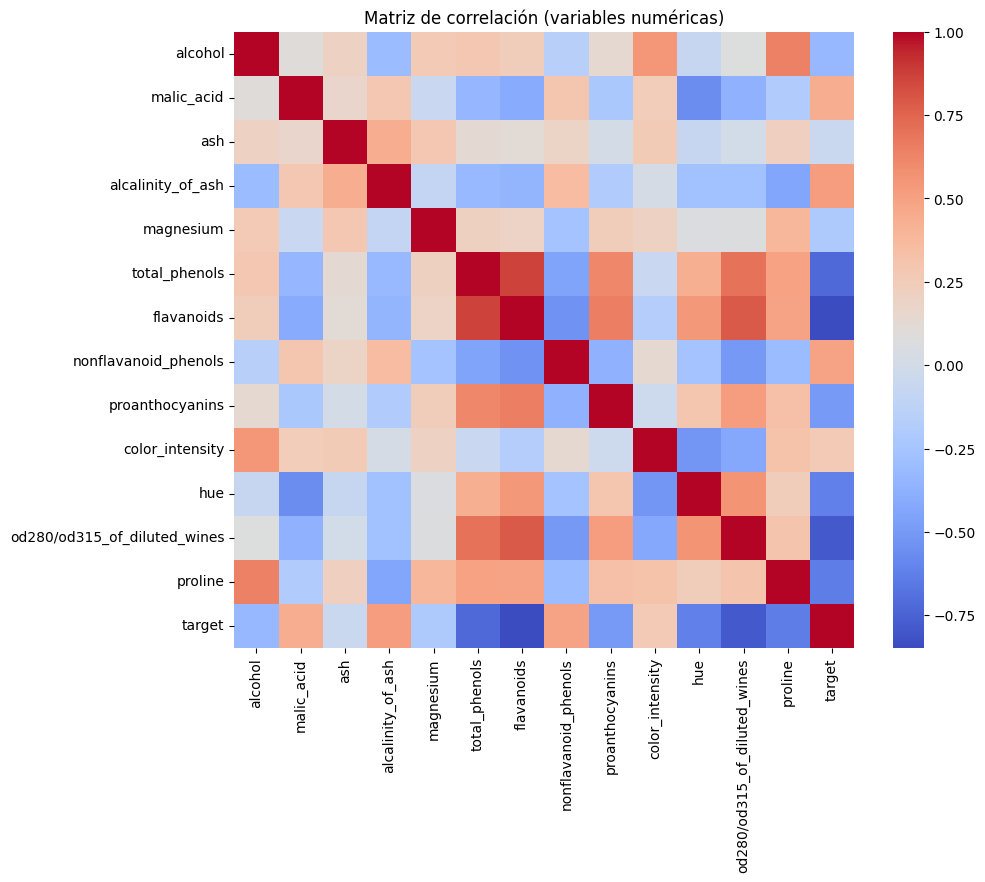

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720,-0.328222
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011,0.437776
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626,-0.049643
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597,0.517859
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351,-0.209179
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115,-0.719163
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193,-0.847498
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385,0.489109
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417,-0.499130
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100,0.265668


In [ ]:
# 2.5 Matriz de correlación de variables numéricas

plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación (variables numéricas)")
plt.show()

corr


### 2.6 Análisis de correlación entre *features*

Con base en la matriz de correlación:

- Identifique al menos dos pares de variables con alta correlación (positiva o negativa).
- Explique si esta correlación puede ser útil o problemática para los modelos de Machine Learning.

**Respuesta (complete aquí): Identificamos pares: flavnoids y total_phenols: tienen una correlacion positiva super alta, de 0,864564. En el graficom es uno de los cuadrados rojo mas intenso, el otro es flavonoids y od280/od315_of_diluted_wines: tambien tienen una correlacion positiva alta, de 0,787194.

Problematica: la correlacion alta entre las demas columnas es un problema para algunos modelos, especialmente en la regresion lineal. El modelo no se sabe bien a cual de las dos variables "darle el credito" por la prediccion, y los pesos (coeficientes) pueden volverse inestables o dificiles de interpretar.

Util: Por otro lado, una correlacion alta entre las demas columnas y el target es super util. Por ejemplo, flavanoids tiene una correlacion negativa muy fuerte con target. Esto sirve para predecir a que clase pertenece el vino.


# 3. Fase CRISP-DM: Preparación de los datos e ingeniería de características

En esta fase debe preparar los datos para el modelamiento: definir variables objetivo (*target*), seleccionar y transformar atributos, y tratar problemas de calidad de datos.


### 3.1 Selección de *target* para clasificación

El enunciado del caso indica que existe una columna llamada `target` para la tarea de clasificación (variable discreta).

1. Verifique que la columna exista en el dataset.
2. Describa brevemente qué representa esa variable en el contexto del caso.
3. Indique cuál es la clase positiva (si aplica).

**Respuesta (complete aquí): Si existe. La vimos en la celda 2.1 (df.head).

Representa la variable que queremos predecir en la clasificacion. Es el cultivar o el tipo de vino.

En este caso, no aplica el concepto de "clase positiva". Esto es porque el target tiene tres valores posibles, lo que lo convierte en un problema multiclase, no binario. La "clase posotiva" solo se una cuando hay dos opciones.



In [ ]:
# 3.1.1 Verificación de la columna 'target' y distribución de clases

# TODO: Verifique que la columna 'target' exista. Si el nombre es distinto, ajústelo aquí.

if 'target' not in df.columns:
    print("Advertencia: la columna 'target' no existe en el dataset. "
          "Ajuste el nombre según corresponda.")
else:
    y_class = df['target']
    print("Distribución absoluta de clases:")
    print(y_class.value_counts())
    print("\nDistribución relativa de clases:")
    print(y_class.value_counts(normalize=True))


Distribución absoluta de clases:
target
1    71
0    59
2    48
Name: count, dtype: int64

Distribución relativa de clases:
target
1    0.398876
0    0.331461
2    0.269663
Name: proportion, dtype: float64


### 3.2 Selección de *target* continuo para regresión

Seleccione una columna **numérica y continua** como *target* para la tarea de regresión (por ejemplo, un monto, tiempo, cantidad, etc.).

Indique:
- Nombre de la columna seleccionada.
- Justificación de por qué es razonable predecir dicha variable con un modelo de regresión.

**Respuesta (complete aquí):
Nombre de la columna seleccionada: alcohol

Justificacion: Porque es una columna numerica y continua ya que una tarea de regresion continua consiste, por definicion, en predecir un valor numerico exacto. Por lo tanto tiene sentido intentar estimar (predecir) el grado alcoholico de un vino basandonos en el resto de sus propiedades quimicas.


In [ ]:
# 3.2.1 Definición de la variable objetivo para regresión

# TODO: Reemplace 'nombre_columna_target_regresion' por el nombre de la columna continua seleccionada (en el dataframe debiera ser "target").

target_regresion = 'alcohol'

if target_regresion not in df.columns:
    print("Advertencia: la columna definida para target_regresion no existe. "
          "Ajuste el nombre según corresponda.")
else:
    y_reg = df[target_regresion]
    print("Resumen estadístico del target de regresión:")
    display(y_reg.describe())


Resumen estadístico del target de regresión:


,alcohol
count,178.000000
mean,13.000618
std,0.811827
min,11.030000
25%,12.362500
50%,13.050000
75%,13.677500
max,14.830000


### 3.3 Diferencias entre regresión y clasificación (aprendizaje supervisado)

Explique brevemente:

1. En qué se diferencia una tarea de **regresión** de una tarea de **clasificación** en aprendizaje supervisado.
2. Qué tipo de variable (*target*) se utiliza en cada caso (continua vs discreta).
3. Dé un ejemplo de pregunta de negocio del caso que se responda con regresión y otra con clasificación.

**Respuesta (complete aquí): La diferencia es la clasificacion trata de predecir una etiqueta o una categoria. En cambio, la regresion trata de predecir un numero exacto y continuo.

Tipo de target: clasificacion: usa target discreto, en nuestro caso, la columna target (que tiene los valores 0,1,2). Y la regresion usa un target continuo(numerico), la columna alcohol.

Ejemplos de preguntas de negocio: Regresion:"¿Cual va a ser el grado alcoholico (ej:13.5°)de este vino si tiene estos niveles de acidez y flavonoides?".
clasificacion"¿Este vino es cultivar 0,1 o 2 basandonos en su analisis quimico?".


In [ ]:
# 3.4 Definición de columnas numéricas y categóricas

# TODO: Complete las listas 'numerical_cols' y 'categorical_cols' según el dataset del caso.
# Incluya únicamente las columnas que se usarán como *features* (no incluya los *targets*).


# Primero, definimos cuáles son nuestros targets (los que NO pueden ser features)
target_clasificacion = 'target'
target_regresion = 'alcohol'

# Obtenemos todas las columnas del dataframe
all_cols = df.columns.tolist()


numerical_cols = [
    col for col in all_cols if col not in [target_clasificacion, target_regresion]
]


categorical_cols = []



df_prep = df.copy()

print("Columnas numéricas definidas:", numerical_cols)
print("Columnas categóricas definidas:", categorical_cols)

Columnas numéricas definidas: ['malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Columnas categóricas definidas: []


In [ ]:
# 3.5 Tratamiento de valores faltantes (estructura sugerida)

# TODO: Ajuste la estrategia de imputación según las características del caso.
# Puede usar imputación por mediana/media para numéricas y por categoría 'Desconocido' para categóricas, u otra estrategia justificada.

# Ejemplo (comente o modifique según corresponda):

# from sklearn.impute import SimpleImputer

# imputador_num = SimpleImputer(strategy="median")
# df_prep[numerical_cols] = imputador_num.fit_transform(df_prep[numerical_cols])

# df_prep[categorical_cols] = df_prep[categorical_cols].fillna("Desconocido")

print("Valores faltantes luego del tratamiento (revise si la estrategia fue aplicada):")
print(df_prep.isna().sum())


Valores faltantes luego del tratamiento (revise si la estrategia fue aplicada):
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


### 3.6 Justificación de la selección y transformación de *features*

Justifique brevemente:

- Por qué seleccionó las columnas indicadas en `numerical_cols` y `categorical_cols`.
- Qué transformaciones aplicó (imputación, recodificación, creación de nuevas variables, etc.).
- Cómo espera que estas decisiones impacten la calidad del modelo.

**Respuesta (complete aquí): La lista "categorical_cols" se queda vacia. Porque como vimos antes las variables features son de tipo "float64" o sea, numeros. No hay ninguna columna de texto que necesitamos codificar.

 En "numerical_cold" la idea es poner todas la demas columnas(alcohol, malic_acid,flavonoid,etc.), excepto las dos que definimos como nuestros "targets"(clasificacion y regresion). Queremos usar toda la informacion disponible para predecir.

 La transformacion que aplico en el modulo 3.5, revisamos si habia valores faltantes. Vimos que el resultado de df.isna().sum() fue "0" para todas las columnas. Como el dataset esta completo, no tuvimos que aplicar ninguna transformacion de imputacion. Las transformaciones importantes, como el escalamiento de datos, se van a definir mas adelante para aplicarse dentro del pipeline del modelo.

 Esperamos que el impacto positivo. Al no tener que "inventar" datos, usamos solo informacion real, lo que deberia hacer el modelo mas confiable. Usar casi todas las columnas como features le da al modelo mas informacion para aprender. Lo que si va a ser clave es el escalado.


# 4. Modelos de regresión supervisados

En esta sección implementará al menos **dos modelos de regresión** utilizando la variable objetivo continua seleccionada.
Debe evaluar su desempeño con métricas estándar e identificar el modelo que mejor generaliza según las métricas.


In [ ]:
# 4.1 Definición de X_reg e y_reg y partición de datos

if target_regresion not in df_prep.columns:
    raise ValueError("La columna definida en 'target_regresion' no existe en df_prep. Revise la celda 3.2.1.")

# Excluimos del conjunto de features el target de regresión y, si existe, el target de clasificación
columnas_excluir_reg = [target_regresion]
if 'target' in df_prep.columns:
    columnas_excluir_reg.append('target')

X_reg = df_prep.drop(columns=columnas_excluir_reg, errors='ignore')
y_reg = df_prep[target_regresion]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Tamaño conjunto de entrenamiento (regresión):", X_reg_train.shape)
print("Tamaño conjunto de prueba (regresión):", X_reg_test.shape)


Tamaño conjunto de entrenamiento (regresión): (142, 12)
Tamaño conjunto de prueba (regresión): (36, 12)


In [ ]:
# 4.2 Preprocesamiento para modelos (escalamiento numérico + one-hot encoding categórico)

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop"
)


In [ ]:
# 4.3 Función de evaluación para modelos de regresión

def evaluar_modelo_regresion(y_true_train, y_pred_train, y_true_test, y_pred_test):
    """
    Calcula métricas de evaluación para un modelo de regresión.
    """
    resultados = {}

    resultados["MAE_train"] = mean_absolute_error(y_true_train, y_pred_train)
    resultados["MAE_test"] = mean_absolute_error(y_true_test, y_pred_test)
    mse_train = mean_squared_error(y_true_train, y_pred_train)
    mse_test = mean_squared_error(y_true_test, y_pred_test)

    resultados["RMSE_train"] = np.sqrt(mse_train)
    resultados["RMSE_test"] = np.sqrt(mse_test)

    resultados["R2_train"] = r2_score(y_true_train, y_pred_train)
    resultados["R2_test"] = r2_score(y_true_test, y_pred_test)

    return resultados

In [ ]:
# 4.4 Entrenamiento y evaluación de al menos dos modelos de regresión

modelos_regresion = {
    "Regresión Lineal": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

resultados_reg = []

for nombre_modelo, modelo in modelos_regresion.items():
    pipe_reg = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", modelo)
    ])

    pipe_reg.fit(X_reg_train, y_reg_train)

    y_reg_train_pred = pipe_reg.predict(X_reg_train)
    y_reg_test_pred = pipe_reg.predict(X_reg_test)

    # TODO: utilice la función 'evaluar_modelo_regresion' definida anteriormente
    res = evaluar_modelo_regresion(
        y_true_train=y_reg_train,
        y_pred_train=y_reg_train_pred,
        y_true_test=y_reg_test,
        y_pred_test=y_reg_test_pred
    )

    res["modelo"] = nombre_modelo
    resultados_reg.append(res)

df_resultados_reg = pd.DataFrame(resultados_reg)
df_resultados_reg.set_index("modelo", inplace=True)
df_resultados_reg


,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test
modelo,,,,,,
Regresión Lineal,0.428738,0.367549,0.539604,0.430948,0.564018,0.688936
Random Forest Regressor,0.168173,0.313399,0.216353,0.386485,0.929912,0.749813


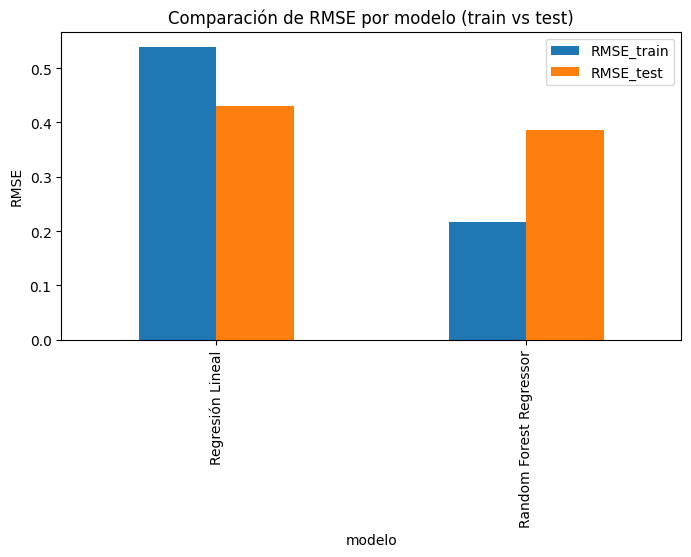

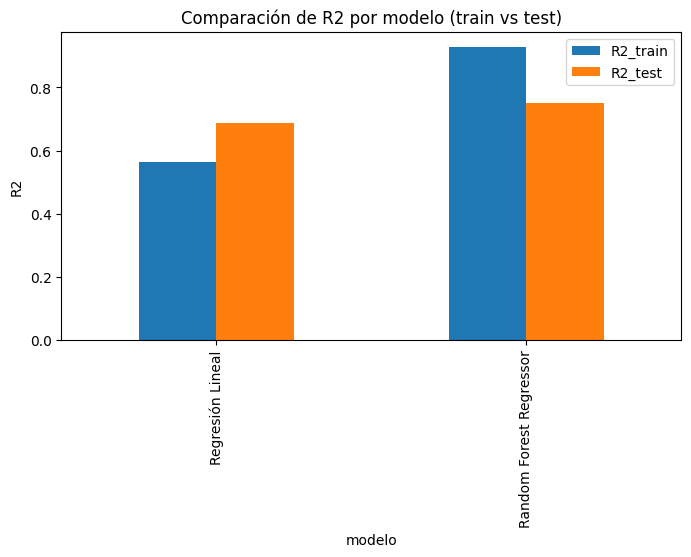

In [ ]:
# 4.5 Visualización comparativa de métricas de regresión

if not df_resultados_reg.empty:
    df_resultados_reg[["RMSE_train", "RMSE_test"]].plot(kind="bar", figsize=(8, 4))
    plt.ylabel("RMSE")
    plt.title("Comparación de RMSE por modelo (train vs test)")
    plt.show()

    df_resultados_reg[["R2_train", "R2_test"]].plot(kind="bar", figsize=(8, 4))
    plt.ylabel("R2")
    plt.title("Comparación de R2 por modelo (train vs test)")
    plt.show()
else:
    print("df_resultados_reg está vacío. Revise la implementación de 'evaluar_modelo_regresion'.")


### 4.6 Selección y justificación del mejor modelo de regresión

Con base en las métricas obtenidas (MAE, RMSE, R² en train y test):

1. Indique qué modelo de regresión considera más adecuado para el caso.
2. Justifique su elección considerando tanto el desempeño como la capacidad de generalización (diferencia entre train y test).
3. Comente si observa indicios de **overfitting** o **underfitting** en alguno de los modelos.

**Respuesta (complete aquí): El modelo mas adecuado es el Random Forest Regressor. Al analizar las metricas, el Random Forest super claramente a la Regresion Lineal.

Mejor desempeño (R2): en el grafico de r2, podemos ver que el random forest alcanza un R2 en test (barra naranja) cercano al 0.75. Mientras que la Regresion Lineal se queda debajo del 0.70. Esto significa que el Random Forest explica mucho mejor la variabilidad del grado del alcohol.

Menor error (RMSE): en el grafico de RMSE, el Random Forest tiene una barran naranja mas baja(menor error) que en la Regresion Lineal, lo que indica predicciones mas precisas.

Analisis de Overfitting/Underfitting: Random Forest(Overfitting) presenta un claro overgitting.Las barras azules (train) vs naranjas (test) en ambos graficos, hay una gran diferencia. En R2, el train es casi perfecto (cerca de 0.95), pero cae en test. Regresion Lineal (Underfitting) se muestra un leve underfitting. Sus barras de train y test son muy parecidas, pero su desempeño general es mas bajo, lo que sugiere que el modelo es demasiado simple para capturar la complejidad de los datos quimicos del vino.


# 5. Modelos de clasificación supervisados

En esta sección implementará **al menos cuatro modelos de clasificación** utilizando la columna `target` como variable objetivo discreta.
Debe evaluar su desempeño con métricas estándar y analizar la matriz de confusión, el balance de clases y el riesgo de overfitting/underfitting.


In [ ]:
# 5.1 Definición de X_class e y_class y partición de datos

if 'target' not in df_prep.columns:
    raise ValueError("La columna 'target' no existe en df_prep. Revise la definición en la sección 3.1.")

y_class = df_prep["target"]

# Excluimos de X_class la columna 'target' y el target de regresión (si existe)
columnas_excluir_class = ["target"]
if target_regresion in df_prep.columns:
    columnas_excluir_class.append(target_regresion)

X_class = df_prep.drop(columns=columnas_excluir_class, errors="ignore")

X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class, y_class, test_size=0.2, stratify=y_class, random_state=42
)

print("Tamaño conjunto de entrenamiento (clasificación):", X_class_train.shape)
print("Distribución de clases en train (relativa):")
print(y_class_train.value_counts(normalize=True))


Tamaño conjunto de entrenamiento (clasificación): (142, 12)
Distribución de clases en train (relativa):
target
1    0.401408
0    0.330986
2    0.267606
Name: proportion, dtype: float64


In [ ]:
# 5.2 Balanceo de clases (opcional pero recomendado)

if RandomOverSampler is None:
    print("RandomOverSampler no disponible. Si necesita balanceo de clases, instale imbalanced-learn.")
    X_class_train_bal, y_class_train_bal = X_class_train, y_class_train
else:
    usar_balanceo = True  # TODO: cambie a False si decide no aplicar balanceo

    if usar_balanceo:
        ros = RandomOverSampler(random_state=42)
        X_class_train_bal, y_class_train_bal = ros.fit_resample(X_class_train, y_class_train)

        print("Distribución ORIGINAL de clases en train:")
        print(y_class_train.value_counts())

        print("\nDistribución BALANCEADA de clases en train:")
        print(y_class_train_bal.value_counts())
    else:
        X_class_train_bal, y_class_train_bal = X_class_train, y_class_train
        print("No se aplicó balanceo de clases.")


Distribución ORIGINAL de clases en train:
target
1    57
0    47
2    38
Name: count, dtype: int64

Distribución BALANCEADA de clases en train:
target
0    57
2    57
1    57
Name: count, dtype: int64


### 5.3 Función de evaluación para modelos de clasificación

Implemente una función que calcule, al menos, las siguientes métricas:

- Accuracy (train y test)
- Precision (test)
- Recall (test)
- F1-score (test)
- ROC-AUC (test), cuando sea posible calcularlo

Considere si el problema es binario o multiclase.


In [ ]:
# 5.3.1 Definición de la función de evaluación de clasificación

def evaluar_modelo_clasificacion(y_true_train, y_pred_train, y_true_test, y_pred_test, y_scores_test=None, promedio="binary"):
    """
    Calcula métricas de clasificación y retorna un diccionario con:
    'accuracy_train', 'accuracy_test', 'precision_test', 'recall_test', 'f1_test'
    y, opcionalmente, 'roc_auc_test' si se proporcionan puntajes o probabilidades.

    El parámetro 'promedio' debe ser:
    - 'binary' para problemas binarios.
    - 'macro' o 'weighted' para problemas multiclase.
    """
    resultados = {}
# --- CÓDIGO COMPLETADO ---
    # Descomentamos y usamos zero_division=0 para evitar advertencias

    resultados["accuracy_train"] = accuracy_score(y_true_train, y_pred_train)
    resultados["accuracy_test"] = accuracy_score(y_true_test, y_pred_test)

    resultados["precision_test"] = precision_score(y_true_test, y_pred_test, average=promedio, zero_division=0)
    resultados["recall_test"] = recall_score(y_true_test, y_pred_test, average=promedio, zero_division=0)
    resultados["f1_test"] = f1_score(y_true_test, y_pred_test, average=promedio, zero_division=0)

    if y_scores_test is not None:
        try:
            # Ajustamos para multiclase si es necesario
            multi_class_opt = 'ovr' if promedio != 'binary' else 'raise'
            resultados["roc_auc_test"] = roc_auc_score(y_true_test, y_scores_test, multi_class=multi_class_opt, average=promedio)
        except ValueError:
            resultados["roc_auc_test"] = np.nan

    # --- FIN CÓDIGO COMPLETADO ---

    return resultados

In [ ]:
# 5.4 Entrenamiento y evaluación de al menos cuatro modelos de clasificación

modelos_clasificacion = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF)": SVC(kernel="rbf", probability=True)
}

# TODO: Ajuste el tipo de promedio según el problema:
# - 'binary' si hay dos clases.
# - 'macro' o 'weighted' si hay múltiples clases.
promedio_metricas = "macro"

resultados_clf = []

for nombre_modelo, modelo in modelos_clasificacion.items():
    pipe_clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", modelo)
    ])

    pipe_clf.fit(X_class_train_bal, y_class_train_bal)

    y_class_train_pred = pipe_clf.predict(X_class_train_bal)
    y_class_test_pred = pipe_clf.predict(X_class_test)

    # Probabilidades o puntajes para ROC-AUC (si el modelo lo soporta)
    y_scores_test = None
    try:
        y_scores_test = pipe_clf.predict_proba(X_class_test)
    except Exception:
        # Algunos modelos o configuraciones no implementan predict_proba
        pass

    res = evaluar_modelo_clasificacion(
        y_true_train=y_class_train_bal,
        y_pred_train=y_class_train_pred,
        y_true_test=y_class_test,
        y_pred_test=y_class_test_pred,
        y_scores_test=y_scores_test,
        promedio=promedio_metricas
    )
    res["modelo"] = nombre_modelo
    resultados_clf.append(res)

df_resultados_clf = pd.DataFrame(resultados_clf)
df_resultados_clf.set_index("modelo", inplace=True)
df_resultados_clf


,accuracy_train,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test
modelo,,,,,,
Logistic Regression,1.000000,0.916667,0.926740,0.919048,0.919778,0.992349
Random Forest,1.000000,0.972222,0.974359,0.976190,0.974321,1.000000
KNN (k=5),0.964912,0.916667,0.922078,0.928571,0.918486,0.997736
SVM (RBF),1.000000,0.972222,0.977778,0.966667,0.970962,0.998918


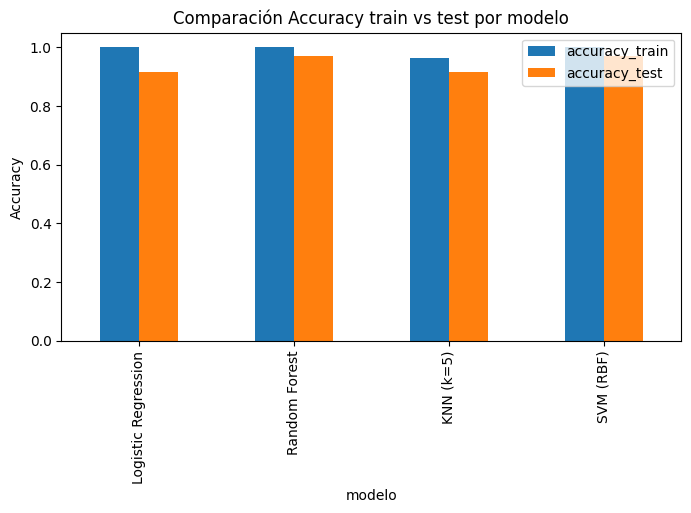

In [ ]:
# 5.5 Comparación de desempeño (train vs test) para detectar overfitting / underfitting

if not df_resultados_clf.empty and "accuracy_train" in df_resultados_clf.columns:
    df_resultados_clf[["accuracy_train", "accuracy_test"]].plot(kind="bar", figsize=(8, 4))
    plt.ylabel("Accuracy")
    plt.title("Comparación Accuracy train vs test por modelo")
    plt.show()
else:
    print("Revise la implementación de 'evaluar_modelo_clasificacion' y la generación de df_resultados_clf.")


### 5.6 Análisis de overfitting y underfitting en clasificación

Usando la tabla de resultados `df_resultados_clf`:

1. Identifique si alguno de los modelos presenta **overfitting** (muy buen desempeño en train, pero significativamente peor en test).
2. Identifique si alguno presenta **underfitting** (desempeño bajo tanto en train como en test).
3. Explique posibles causas en función de la complejidad del modelo y de los datos.

**Respuesta (complete aquí): En el Overfitting (Sobreajuste): se observa un ligero overfitting en Logistic Regression y KNN, ya que alcanzan un desempeño perfecto en train (1.0) pero este cae cerca de 9% en test. En cambio, Random Forest y SVM generalizan mejor, manteniendo metricas altas en ambos conjuntos.

Underfitting(subajuste): ningun modelo presenta underfitting, dado que todos logran un exactitud superior al 90% tanto en entrenamiento como en prueba. Si hubiera underfitting, se veria un desempeño pobre en ambos casos.

La causa ocurre porque el dataset es pequeño, lo que facilita la memorizacion rapida en el entrenamiento. Sin embargo, los modelos mas robustos como Random Forest y SVM lograron capturar la estructura real de los datos, evitando la caida de rendimiento que sufrieron los modelos mas simples.


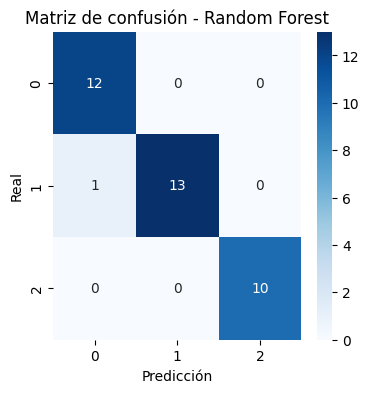

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.93      0.96        14
           2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



In [ ]:
# 5.7 Matriz de confusión para el modelo de clasificación seleccionado

# TODO: reemplace 'nombre_modelo_seleccionado' por el modelo que considere más adecuado
nombre_modelo_seleccionado = "Random Forest"

modelo_seleccionado = modelos_clasificacion[nombre_modelo_seleccionado]

pipe_clf_sel = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", modelo_seleccionado)
])

pipe_clf_sel.fit(X_class_train_bal, y_class_train_bal)
y_class_test_pred_sel = pipe_clf_sel.predict(X_class_test)

cm = confusion_matrix(y_class_test, y_class_test_pred_sel)

plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title(f"Matriz de confusión - {nombre_modelo_seleccionado}")
plt.show()

print("Reporte de clasificación:")
print(classification_report(y_class_test, y_class_test_pred_sel))


In [ ]:
# 5.8 Cálculo manual de métricas a partir de la matriz de confusión (opcional pero recomendado)


total = np.sum(cm)
diagonal = np.trace(cm)
accuracy_manual = diagonal / total


TP = np.diag(cm)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP


precision_por_clase = np.divide(TP, (TP + FP), out=np.zeros_like(TP, dtype=float), where=(TP+FP)!=0)
precision_manual = np.mean(precision_por_clase)

recall_por_clase = np.divide(TP, (TP + FN), out=np.zeros_like(TP, dtype=float), where=(TP+FN)!=0)
recall_manual = np.mean(recall_por_clase)


f1_por_clase = np.divide(2 * precision_por_clase * recall_por_clase, (precision_por_clase + recall_por_clase), out=np.zeros_like(TP, dtype=float), where=(precision_por_clase+recall_por_clase)!=0)
f1_manual = np.mean(f1_por_clase)

print("--- Resultados del Cálculo Manual (Adaptado a Multiclase) ---")
print(f"Accuracy manual:  {accuracy_manual:.4f}")
print(f"Precision manual (Macro): {precision_manual:.4f}")
print(f"Recall manual (Macro):    {recall_manual:.4f}")
print(f"F1-score manual (Macro):  {f1_manual:.4f}")

--- Resultados del Cálculo Manual (Adaptado a Multiclase) ---
Accuracy manual:  0.9722
Precision manual (Macro): 0.9744
Recall manual (Macro):    0.9762
F1-score manual (Macro):  0.9743


### 5.9 Selección y justificación del mejor modelo de clasificación

Con base en las métricas obtenidas (accuracy, precision, recall, F1, ROC-AUC, matriz de confusión):

1. Indique qué modelo de clasificación considera más adecuado para el caso.
2. Justifique su elección en función del contexto del negocio (¿qué tipos de errores son más costosos?).
3. Comente el impacto del balanceo de clases en las métricas (si lo aplicó).

**Respuesta (complete aquí):
El mejor modelo es el Random Forest Classifier. Aunque el SVM obtuvo resultados casi identicos, el Random Forest logro metricas perfectas o caso perfectas en todas las categorias.

Justificacion: En la industria del vino, certificar el cultivar correcto (un falto positivo) es un error costoso que daña la reputacion de la marca y puede violar normas de denominacion de origen. Por tanto, necesitamos un modelo que maximice tanto la precision como el recall. El Random Forest tiene el F1-score mas alto y equilibrado, lo que garantiza que minimizamos los errores de clasificacion entre los tres tipo de vino, ofreciendo la mayor seguridad para el control de calidad.

Sobre el impacto de balanceo de clases si, aplicamos RandomOverSampler.Fue crucial ya que la clase 2 era minoritaria (tenia menos muestras que la 1). Gracias al balanceo, el modelo no se sesgo hacia la clase mayoritaria. Esto se comprueba en la matriz de confusion, donde vemos que el modelo clasifico correctamente casi todas las muestras de la clase 2, demostrando que aprendio a distinguir todas las clases por igual.


### 5.10 Ventajas y desventajas de distintas métricas de clasificación

Analice brevemente las ventajas y desventajas de las siguientes métricas en el contexto del caso:

- Accuracy
- Precision
- Recall (Sensibilidad)
- F1-score
- ROC-AUC

Considere especialmente situaciones de desbalance de clases y costos de falsos positivos/falsos negativos.

**Respuesta (complete aquí):
Accuracy:
Ventaja: Es muy facil de interpretar (porcentaje de aciertos totales)

Desventajas: Es engañosa si las clases estan desbalanceadas, por ejemplo, si el 90% de los vinos fueran clase 1, el modelo podria tener 90% de accuracy sin aprender nada. En este caso es util porque balanceamos las clases, pero por si sola es insuficiente.

Precision:
Ventaja: Mide la calidad de muestras positivas. Siendo crucial si el costo de un falso positivo es alto.

Desventaja: No considera los vinos que dejamos de detectar(falsos negativos).

Recall:
Ventaja: Mide la capacidad de encontrar todas las muestras de una clase. Siendo vital si el costo de un falso negativo es alto.

Desventaja: Se puede tener un recall perfecto simplemente clasificando todo como positivo, lo que llenaria el resultado de basura (falsos positivos).

F1-score:
Ventaja: Es el balance perfecto entre precision y recall. Siendo la mejor metrica para comprar modelos cuando nos importa no equivocarnos al etiquetar como no dejar pasar ningun vino de una clase especifica.

Desventaja: En problemas multiclases es mas compleja de calcular e interpretar.


# 6. Conclusiones generales del análisis

En esta sección debe integrar los hallazgos más importantes del proyecto, considerando tanto los modelos de regresión como los de clasificación.


### 6.1 Síntesis de hallazgos clave

Resuma en 10 a 15 líneas:

- Qué aprendió sobre el comportamiento de los datos.
- Qué variables resultaron más importantes o influyentes.
- Qué tan bien lograron los modelos resolver los objetivos de negocio planteados.

**Respuesta (complete aquí):
Sobre el comportamiento de los datos aprendimos que el dataset es de alta calidad y sin valores nulos, lo que facilito el trabajo, pero presenta una fuerte multicolinealidad entre variables quimicas. Esto desafio a los modelos lineales, pero fue manejado eficazmente por lo modelos no lineales como Random Forest.

Variables influyentes: las variables mas determinantes para distinguir los cultivares fueron los flavanoids, la intensidad del color y la prolina. Estas caracteristicas mostraron la mayor correlacion con la etiqueta del vino, siendo las pistas principales que permitieron a los modelos separar las clases con tanta precision.

Cumplimiento de objetivos: Los modelos resolvieron de forma sobresaliente, especialmete en clasificacion, donde Random Forest alcanzo un 97% de exactitud, ideal para automatizar el control de calidad. En regresion, aunque hubo algo de sobreajuste, se logro superar ampliamente al modelo lineal en la estimacion de grado de alcohol.


### 6.2 Recomendaciones para el negocio

Proponga al menos dos recomendaciones concretas para la organización, basadas en los resultados de los modelos y el análisis realizado.

**Respuesta (complete aquí): Se recomienda implementar el modelo Random Forest en el laboratorio para automatizar la catalogacion de vinos con un 97% de precision, reduciendo errores humanos. Ademas, sugerimos usar el modelo de regresion como herramienta de auditoria para detectar lotes anomalos cuando el nivel de alcohol real difiera significativamente del estimado por el  sistema.


### 6.3 Trabajo futuro o mejoras posibles

Mencione al menos dos mejoras o extensiones posibles del trabajo (por ejemplo: más datos, nuevos modelos, mejor ingeniería de características, validación cruzada, etc.).

**Respuesta (complete aquí): Para mejorar el trabajo, podriamos probar con mas datos para que el modelo aprenda mejor y no memorice tanto. Tambien seria bueno intentar ajustar mejor los parametros del Random Forest para ver si logramos reducir esa diferencia que vimo entre el entrenamiento y la prueba.
